# Homework 2 Part 1 - Solutions

---

# Exercise 1 (10 points)

**Consider a training set containing positive natural numbers - including zero - ($x\in\mathbb{N}_0$) for 2 classes, $C_0$ and $C_1$. The training set has 100 samples for class $C_0$ and 50 for $C_1$.**

**Suppose that you have reason to believe that samples belonging from $C_0$ are drawn from a Poisson random variable with parameter $\lambda>0$, and samples belonging to $C_1$ are drawn from a Binomial random variable with parameters $n\in\mathbb{N}_0$ and $p\in[0,1]$. In other words, the data likelihoods for $C_0$ and $C_1$ are as follows:**

\begin{align*}
    p(x|C_0) &= \frac{\lambda^x e^{-\lambda}}{x!}\\
    p(x|C_1) &= \begin{pmatrix}n\\x\end{pmatrix} p^x (1-p)^{n-x}
\end{align*}

**where $\begin{pmatrix}n\\x\end{pmatrix} = \frac{n!}{x!(n-x)!}$ is the binomial coefficient of "$n$ choose $x$".**

**Consider $\lambda=2$, $n=10$ and $p=0.5$. Consider the test point $x=3$. Use the Naive Bayes classifier to predict a class label for $x=3$. Show your work.**

The prior probability for each class can be estimated as its relative frequency in the training set, namely

\begin{align*}
    p(C_1) = \frac{100}{150}=\frac{2}{3} \text{ and } p(C_2) = \frac{50}{150}=\frac{1}{3}
\end{align*}

For the provided parameter values, the data likelihood for class 1 and class 2 are defined as:

\begin{align*}
    p(x|C_0) &= \frac{2^3 e^{-2}}{3!} = \frac{4e^{-2}}{3} \\
    p(x|C_1) &= \begin{pmatrix}10\\3\end{pmatrix} 0.5^3 (1-0.5)^{10-3} = \frac{120}{2^{10}}
\end{align*}

For the test point $x=3$, we compute the posterior probability with
\begin{align*}
    P(C_k|x=3) &= \frac{p(x=3|C_k) p(C_k)}{p(x=3)} = \frac{p(x=3|C_k) p(C_k)}{\sum_{j=1}^2 p(x=3|C_j) p(C_j)}
\end{align*}

We now find:

\begin{align*}
    P(C_0|x=3) &= \frac{\frac{4e^{-2}}{3}\times\frac{2}{3}}{\frac{4e^{-2}}{3}\times\frac{2}{3} + \frac{120}{2^{10}}\times\frac{1}{3}} \approx 0.755\\
    P(C_1|x=3) &= \frac{\frac{120}{2^{10}}\times\frac{1}{3}}{\frac{4e^{-2}}{3}\times\frac{2}{3} + \frac{120}{2^{10}}\times\frac{1}{3}} \approx 0.245
\end{align*}

Since $P(C_0|x=3) > P(C_1|x=3)$ then the test point $x=3$ is assigned to class $C_0$.

In [1]:
from scipy.special import binom
import numpy as np

y0 = 4*np.exp(-2)/3
y1 = binom(10,3)/(2**10)

p0 = 2/3
p1 = 1-p0

pos0 = (y0*p0) / (y0*p0 + y1*p1)
pos1 = (y1*p1) / (y0*p0 + y1*p1)

pos0, pos1

(0.7548797050821854, 0.24512029491781465)

---

# Exercise 2 (7 points)

**Consider the Naive Bayes classifier for a binary classification task in a two-dimensional feature space with $P(\mathbf{x}|C_1) \sim G \left(\mu_1, \Sigma_1 \right)$, $P(\mathbf{x}|C_2)\sim G\left(\mu_2, \Sigma_2\right)$ and $P(C_1)=P(C_2)=\frac{1}{2}$, where $\mathbf{x}=\begin{bmatrix}x_1\\x_2\end{bmatrix}$ is a sample observation, $\mu_i$ is the $2\times 1$ mean vector for class $C_i$ and $\Sigma_i$ is the $2\times 2$ covariance matrix for class $C_i$.**

**Let $g_i(x) = \ln(P(\mathbf{x}|C_i)P(C_i))$ be the discriminant function for class $C_i$. Then, let $g(\mathbf{x}) = g_1(\mathbf{x})-g_2(\mathbf{x})$. The Naive Bayes decision rule is defined as:**

\begin{align*}
&\textbf{Choose}\;\; C_1 \;\; \textbf{if} \;\; g(\mathbf{x})>0\\
&\textbf{Choose} \;\; C_2 \;\; \textbf{otherwise}
\end{align*}

1. (3.5 points) **Let $\mu_1=\begin{bmatrix}0\\0\end{bmatrix}$, $\mu_2=\begin{bmatrix}1\\1\end{bmatrix}$ and $\Sigma_1=\Sigma_2=\mathbf{I}$. Find $g(\mathbf{x})$. Show all your work. What is the shape of the decision boundary?**

To compute the data likelihoods, we need to determine the inverse of the covariance matrix. Since they are both the identity matrix $\Sigma_1=\Sigma_2=\mathbf{I}$, we know that $\Sigma_1^{-1}=\Sigma_2^{-1}=\mathbf{I}^{-1}=\mathbf{I}$.

The discriminant function $g_i(x)$, $i=1,2$ is defined as $P(x|C_i)P(C_i)$. We can simplify it by taking $g_i(x)=\ln(P(x|C_i)P(C_i))$. Note that $x=[x_1,x_2]^T$.We have:

\begin{align*}
g_1(x) &= \ln\left(\frac{1}{2}\times\frac{1}{(2\pi)^{2/2}|\Sigma_1|^{1/2}} \exp\left\{-\frac{1}{2}x^T\Sigma_1^{-1}x\right\}\right) \\
& = \ln\left(\frac{1}{2}\right) - \ln(2\pi) - \frac{1}{2}x^Tx\\
& = \ln\left(\frac{1}{2}\right) - \ln(2\pi) - \frac{1}{2}(x_1^2+x_2^2)
\end{align*}

and 

\begin{align*}
g_2(x) &= \ln\left(\frac{1}{2}\times\frac{1}{(2\pi)^{2/2}|\Sigma_2|^{1/2}} \exp\left\{-\frac{1}{2}(x-1)^T\Sigma_2^{-1}(x-1)\right\}\right) \\
& = \ln\left(\frac{1}{2}\right) - \ln(2\pi) - \frac{1}{2}(x-1)^T(x-1)\\
& = \ln\left(\frac{1}{2}\right) - \ln(2\pi) - \frac{1}{2}((x_1-1)^2+(x_2-1)^2)\\
& = \ln\left(\frac{1}{2}\right) - \ln(2\pi) - \frac{1}{2}(x_1^2 + x_2^2 - 2x_1 - 2x_2 +2)
\end{align*}

Now, let $g(x) = g_1(x)-g_2(x)$, we find:

\begin{align*}
g(x) &= -\frac{1}{2}(-2x_1 -2x_2 +2) = x_1 + x_2 -1
\end{align*}

Thus, we decide $C_1$ if $g(x)>0 \iff x_2>-x_1 +1$. As expected, this discriminant function passes through the midpoint of the two means $[0.5,0.5]^T$ since the two categories have the same prior and covariance matrices.

We can visualize this decision boundary as follows:

In [2]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

# Useful Function

def discriminant_fct(X1, X2, p1, x, g, display=True):
    # grid for plotting
    xm, ym = np.meshgrid(x, x)
    X = np.flip(np.dstack([xm,ym]),axis=0)

    # daata likelihoods
    y1 = X1.pdf(X) #P(x|C1)
    y2 = X2.pdf(X) #P(x|C2)
    # visualize data likelihoods
    fig =plt.figure(figsize=(12,5))
    fig.add_subplot(1,2,1)
    plt.imshow(y1, extent=[min(x),max(x),min(x),max(x)])
    plt.colorbar(); plt.title('$P(x|C_1)$', size=20)
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.xticks(fontsize=15); plt.yticks(fontsize=15)
    fig.add_subplot(1,2,2)
    plt.imshow(y2, extent=[min(x),max(x),min(x),max(x)])
    plt.colorbar(); plt.title('$P(x|C_2)$', size=20)
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.xticks(fontsize=15); plt.yticks(fontsize=15)

    # priors
    p2 = 1-p1
    # posterior probability
    pos1 = (y1*p1)/(y1*p1 + y2*p2) # P(C1|x)
    pos2 = (y2*p2)/(y1*p1 + y2*p2) # P(C2|x)
    
    # visualize discriminant function with posterior
    plt.figure(figsize=(8,5))
    plt.imshow(pos1-pos2>0, extent=[min(x),max(x),min(x),max(x)])
    if display:
        plt.plot(x, g, 'r', label='Discriminant function')
        plt.legend()
    plt.colorbar();
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.title('Region to Decide Class 1');

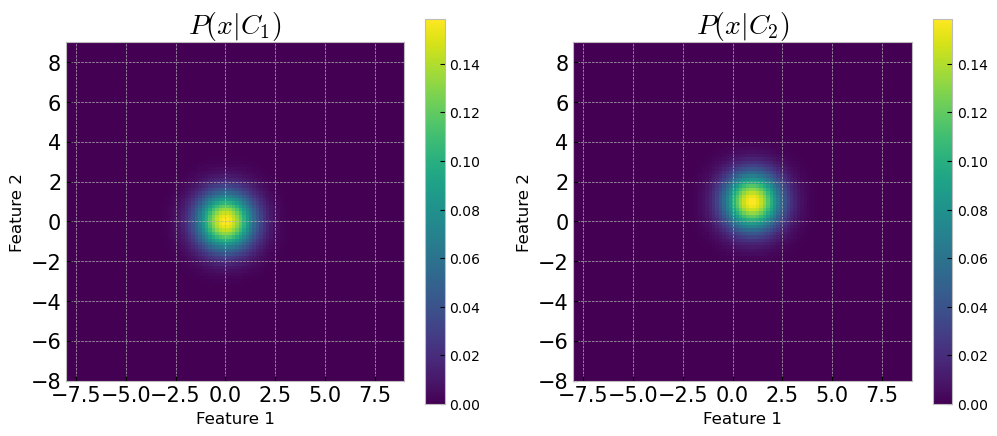

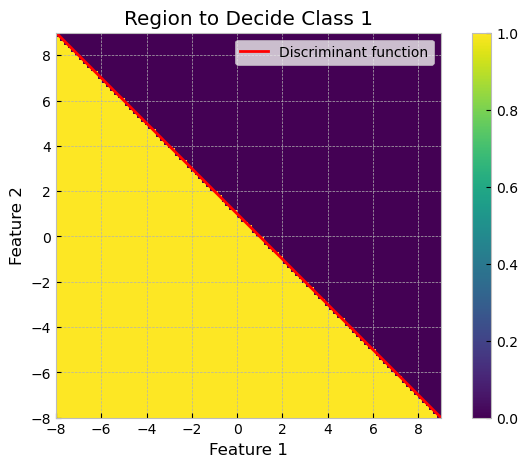

In [3]:
X1 = stats.multivariate_normal(mean=[0,0], cov=np.eye(2))
X2 = stats.multivariate_normal(mean=[1,1], cov=np.eye(2))
p1=1/2
x = np.linspace(-8,9,100)
g = -x + 1
discriminant_fct(X1, X2, p1, x, g)

2. (3.5 points) **Let $\mu_1=\begin{bmatrix}0\\0\end{bmatrix}$, $\mu_2=\begin{bmatrix}1\\1\end{bmatrix}$, $\Sigma_1=\begin{bmatrix}2 & 0.5\\0.5 & 2\end{bmatrix}$ and $\Sigma_2=\begin{bmatrix}5 & 4\\4 & 5\end{bmatrix}$. Find $g(\mathbf{x})$. Show all your work. What is the shape of the decision boundary?**

To compute the data likelihoods, we need to determine the inverse of the covariance matrix. We have $\Sigma_1^{-1} = \begin{bmatrix}8/15 & -2/15 \\ -2/15 & 8/5\end{bmatrix}$ and $\Sigma_2^{-1} = \begin{bmatrix}5/9 & -4/9 \\ -4/9 & 5/9\end{bmatrix}$. Moreover, the determinants are $|\Sigma_1| = \frac{15}{4}$ and $|\Sigma_2| = 9$.

The discriminant function $g_i(x)$, $i=1,2$ is defined as $P(x|C_i)P(C_i)$. We can simplify it by taking $g_i(x)=\ln(P(x|C_i)P(C_i))$. Note that $x=[x_1,x_2]^T$.We have:

\begin{align*}
g_1(x) &= \ln\left(\frac{1}{2}\times\frac{1}{(2\pi)^{2/2}|\Sigma_1|^{1/2}} \exp\left\{-\frac{1}{2}x^T\Sigma_1^{-1}x\right\}\right) \\
& = \ln\left(\frac{1}{2}\right) - \ln(2\pi) -\frac{1}{2}\ln\left(\frac{15}{4}\right) - \frac{1}{2}x^T\Sigma_1^{-1}x\\
& = \ln\left(\frac{1}{2}\right) - \ln(2\pi) -\frac{1}{2}\ln\left(\frac{15}{4}\right) - \frac{1}{2}\left(\frac{8}{15}x_1^2-\frac{2}{15}x_1x_2 -\frac{2}{15}x_1x_2 + \frac{8}{15}x_2^2\right)\\
& = \ln\left(\frac{1}{2}\right) - \ln(2\pi) -\frac{1}{2}\ln\left(\frac{15}{4}\right) - \frac{1}{2}\left(\frac{8}{15}x_1^2-\frac{4}{15}x_1x_2 + \frac{8}{15}x_2^2\right)
\end{align*}

and

\begin{align*}
g_2(x) &= \ln\left(\frac{1}{2}\times\frac{1}{(2\pi)^{2/2}|\Sigma_2|^{1/2}} \exp\left\{-\frac{1}{2}(x-1)^T\Sigma_2^{-1}(x-1)\right\}\right) \\
& = \ln\left(\frac{1}{2}\right) - \ln(2\pi) -\frac{1}{2}\ln(9) - \frac{1}{2}(x-1)^T\Sigma_2^{-1}(x-1)\\
& = \ln\left(\frac{1}{2}\right) - \ln(2\pi) -\frac{1}{2}\ln(9)) - \frac{1}{2}\left(\frac{5}{9}(x_1-1)^2 -\frac{4}{9}(x_1-1)(x_2-1) -\frac{4}{9}(x_1-1)(x_2-1)+\frac{5}{9}(x_2-1)^2\right)
\end{align*}

Let $g(x) = g_1(x)-g_2(x)$. After some simplification, we find:

\begin{align*}
g(x) &= x_1^2 + x_2^2 -28x_1x_2 -10x_1 - 10x_2 +50
\end{align*}

which consists of two hyperbolas.

Thus, we decide $C_1$ if $g(x)>0$.

We can visualize this decision boundary as follows:

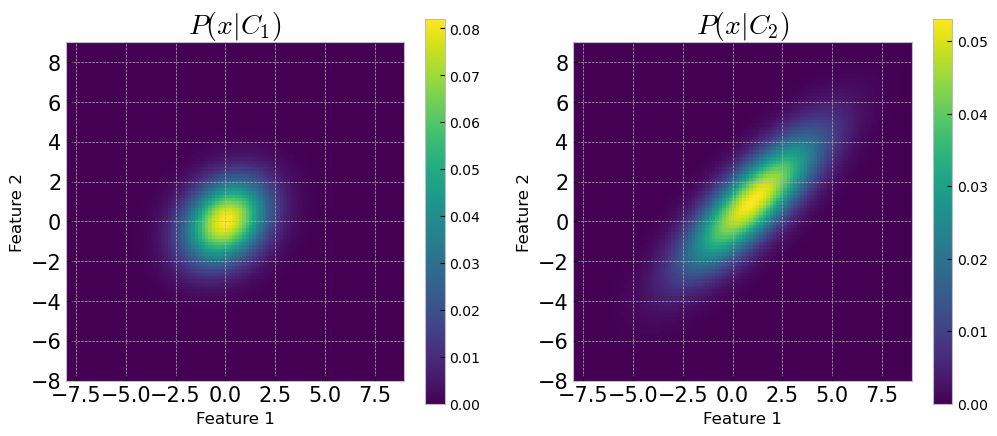

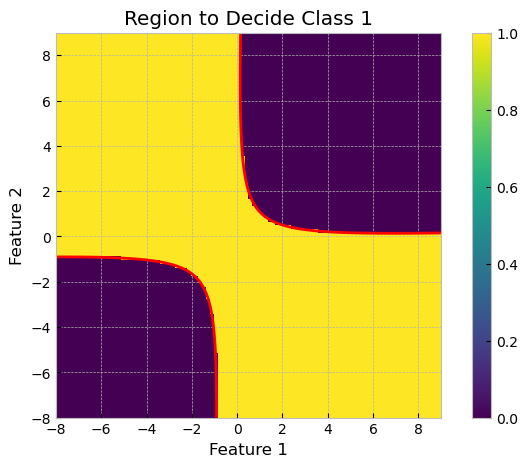

In [4]:
X1 = stats.multivariate_normal(mean=[0,0], cov=[[2,0.5],[0.5,2]])
X2 = stats.multivariate_normal(mean=[1,1], cov=[[5,4],[4,5]])
p1=1/2
x = np.linspace(-8,9,100)
x1, x2 = np.meshgrid(x, x)
discriminant_fct(X1, X2, p1, x, 0, False)
plt.contour(x1, x2, x1**2 + x2**2 -28*x1*x2 -10*x1 - 10*x2 + 50, [1], colors='r');

---

# Exercise 3 (10 points)

**Use the Expectation-Maximization (EM) algorithm to solve for the parameters of an Rayleigh Mixture Model (with $K$ components) given a set of training data $\mathbf{X}=\{x_i\}_{i=1}^N$, where $x_i \geq 0\ \forall i\in\{1,\dots,N\}$. Recall the form of the Rayleigh probability density function is defined as:**

\begin{align*}
    P\left(x|\sigma_k\right) = \frac{x}{\sigma_k^2} e^{-x^2/(2\sigma_k^2)}
\end{align*}

**Answer the following questions:**

1. (2 points) **Assuming your data is i.i.d., write down the observed data likelihood, $\mathcal{L}^0$.**

The observed data likelihood is:

\begin{align*}
    \mathcal{L}^0 = \prod_{i=1}^N \sum_{k=1}^K \pi_k \frac{x_i}{\sigma_k^2} e^{-x_i^2/(2\sigma_k^2)}
\end{align*}

2. (1 point) **Introduce the latent hidden variables $\mathbf{z}$ and write down the complete data likelihood, $\mathcal{L}^c$.**

We can introduce the hidden latent variable $\mathbf{z}$, where $z_i$ corresponds to the Rayleigh component from which sample $x_i$ was drawn from. Moreover, since we have a total of $K$ Rayleigh components, $z_i\in\{1,2,\dots, K\}$.

The complete data likelihood is given by:

\begin{align*}
    \mathcal{L}^c = \prod_{i=1}^N  \pi_{z_i} \frac{x_i}{\sigma_{z_i}^2} e^{-x_i^2/(2\sigma_{z_i}^2)}
\end{align*}

3. (3 points) **Write down the EM optimization function, $Q(\Theta,\Theta^t)$, where $\Theta=\{\pi_k, \sigma_k\}_{k=1}^K$. Your final solution should contain the sum of simple (and simplified) log-terms.**

The EM optimization function is given by:

\begin{align*}
    Q(\Theta, \Theta^t) &= \mathbb{E}_z[\ln(\mathbf{L}^c) | \mathbf{X}, \Theta^t]\\
    &= \sum_{z_i=1}^K \ln(\mathbf{L}^c) P(z_i | x_i, \Theta^t)\\
    &= \sum_{k=1}^K \left[\sum_{i=1}^N \left( \ln(\pi_k) + \ln(x_i) - 2\ln(\sigma_k)  -\frac{x_i^2}{2\sigma_k^2}\right) \right] P(z_i=k|x_i, \Theta^t)\\
    &= \sum_{k=1}^K \left[\sum_{i=1}^N \left( \ln(\pi_k) + \ln(x_i) - 2\ln(\sigma_k)  -\frac{x_i^2}{2\sigma_k^2}\right) \right] C_{ik}
\end{align*}

where $C_{ik} = P(z_i=k|x_i, \Theta^t)$.

4. (2 points) **Derive the update equations for the parameters $\sigma_k$.**

The solution for the parameter $\sigma_k$ is:

\begin{align*}
    \frac{\partial Q(\Theta, \Theta^t)}{\partial \sigma_k} &= 0\\
    \sum_{i=1}^N \left(-\frac{2}{\sigma_k} + \frac{4\sigma_k x_i^2}{(2\sigma_k^2)^2}\right)C_{ik} &= 0\\
    \sum_{i=1}^N \left(-2\sigma_k^2 + x_i^2\right)C_{ik} &= 0\\
    \sum_{i=1}^N 2\sigma_k^2C_{ik} &=\sum_{i=1}^N x_i^2C_{ik}\\
    \sigma_k &= \sqrt{\frac{\sum_{i=1}^N x_i^2C_{ik}}{\sum_{i=1}^N 2C_{ik}}}
\end{align*}

5. (2 points) **Derive the update equations for the parameters $\pi_k$.**

In order to find the solution for $\pi_k$, we must add the constraint $\sum_{k=1}^K \pi_k=1$ to the optimization function:

\begin{align*}
    Q_{\pi}(\Theta,\Theta^t) = Q(\Theta,\Theta^t) - \lambda\left(\sum_{k=1}^N \pi_k -1 \right)
\end{align*}

The solution for $\pi_k$ is then:

\begin{align*}
    \frac{\partial Q_{\pi}(\Theta, \Theta^t)}{\partial \pi_k} &= 0\\
    \sum_{i=1}^N \frac{1}{\pi_k}C_{ik} - \lambda &=0\\
    \pi_k &= \frac{1}{\lambda} \sum_{i=1}^N C_{ik}
\end{align*}

Since $\sum_{k=1}^K \pi_k=1$, we find that: $\sum_{k=1}^K \frac{1}{\lambda} \sum_{i=1}^N C_{ik}=1 \iff \lambda = N$. Hence, the solution for $\pi_k$ is:

\begin{align*}
    \pi_k =\frac{\sum_{i=1}^N C_{ik}}{N}
\end{align*}

---

# Exercise 4 (18 points)

**For each statement below, state whether it is true (T) or false (F) and provide a justification for your answer.**

1. (2 points) **Minimizing the Least Squares objective function with a weight decay term (regularizer) is equivalent to maximizing the data likelihood with a prior on the weights.**

*True.* We can show this analytically. Consider the least squares objective function below with a ridge regularizer:

\begin{align*}
J(\mathbf{w}) = \frac{1}{2}\sum_{i=1}^N (t_i - y_i)^2 + \frac{\lambda}{2}\sum_{j=0}^M w_j^2
\end{align*}

The solution for the parameters $\mathbf{w}$ is found by optimizing $J(\mathbf{w})$:

\begin{align*}
\arg_{\mathbf{w}} \min J(\mathbf{w}) &= \arg_{\mathbf{w}} \max - J(\mathbf{w})\\
&= \arg_{\mathbf{w}} \max \exp\left(-J(\mathbf{w})\right)\\
&= \arg_{\mathbf{w}} \max \exp\left(-\frac{1}{2}\sum_{i=1}^N \left(t_i - y_i\right)^2 - \frac{\lambda}{2} \sum_{j=0}^M w_j^2\right)\\
&= \arg_{\mathbf{w}} \max \prod_{i=1}^N\exp\left(-\frac{1}{2} \left(t_i - y_i\right)^2\right)\prod_{j=0}^M\exp\left(-\frac{\lambda}{2} w_j^2\right)\\
&\propto \arg_{\mathbf{w}} \max \prod_{i=1}^N \mathcal{N}\left(t_i;y_i,1\right)\prod_{j=0}^M \mathcal{N}\left(w_j;0, \frac{1}{\lambda}\right)\\
&= \arg_{\mathbf{w}} \max p(\mathbf{t}| \mathbf{y}(\mathbf{x};\mathbf{w})) p(\mathbf{w}| \lambda)\\
&\propto \arg_{\mathbf{w}} \max p(\mathbf{w}| \mathbf{t})
\end{align*}

We see that adding a regularization penalty term to the objective function is equivalent to adding a prior probability on the parameters. 

For the ridge penalty, the probabilistic model of the prior probability is a Gaussian distribution with mean 0 and variance $1/\lambda$. 

2. (2 points) **The observed data likelihood on $N$ i.i.d. samples $x_i$ (where $x_i\geq0, \forall i$) with a Gamma distribution, $P(x|\alpha,\beta)=\frac{\beta^{\alpha}}{\Gamma(\alpha)}x^{\alpha-1}e^{-\beta x}$, and a prior probability on parameter $\beta$ as another Gamma distribution, $P(\beta|a,b)=\frac{b^a}{\Gamma(a)}\beta^{a-1}e^{-b \beta}$, form a Conjugate Prior relationship.**

*True*. The observed data likelihood for MAP is:

\begin{align*}
    \mathcal{L}^0 &= \left(\prod_{i=1}^N \frac{\beta^{\alpha}}{\Gamma(\alpha)}x_i^{\alpha-1}e^{-\beta x_i}\right)\frac{b^a}{\Gamma(a)}\beta^{a-1}e^{-b \beta}\\
    &\propto \left(\prod_{i=1}^N \beta^{\alpha}e^{-\beta x_i}\right)\beta^{a-1}e^{-b \beta}\\
    &= \beta^{\sum_{i=1}^N \alpha} e^{-\beta\sum_{i=1}^N x_i}\beta^{a-1}e^{-b \beta}\\
    &=\beta^{N\alpha+a-1} e^{-\beta\left(\sum_{i=1}^N x_i +b\right)}
\end{align*}

We find that the resulting posterior has the same parametric form (by a scaling factor) as the prior, thus Gamma-Gamma form a conjugate prior. The parameter updates are as follows:
\begin{align*}
    a^{(t+1)} &\leftarrow a^{(t)} +N\alpha \\
    b^{(t+1)} &\leftarrow b^{(t)} + \sum_{i=1}^N x_i
\end{align*}

3. (2 points) **In MLE estimation we are optimizing the posterior distribution.**

*False.* The Maximum Likelihood Estimation (MLE) finds the parameters of the observed data likelihood in a data-driven approach without any prior assumption on the parameters.

4. (2 points) **Consider $\theta_{\text{MLE}} = \arg_{\theta} \max P(X|\theta)$ and $\theta_{\text{MAP}} = \arg_{\theta} \max P(X|\theta)P(\theta)$. We have that $\theta_{\text{MLE}} = \theta_{\text{MAP}}$ for uniform-distributed priors.**

*True.* We can show this analytically:

\begin{align*}
\theta_{\text{MAP}} =& \arg_{\mathbf{w}} \min P(X|\theta)P(\theta) \\
=& \arg_{\mathbf{w}}\min \begin{cases} P(X|\theta)\frac{1}{b-a}, & \text{if }X\text{ is continuous RV and }X\sim U(a,b)\\ P(X|\theta)\frac{1}{b-a+1}, & \text{if }X\text{ is discrete RV and }X\sim U(a,b) \end{cases}\\
&\; \\
& \text{since }a\text{ and }b\text{ are constants (in either discrete or continuous cases), then }\\
& \; \\
=& \arg_{\mathbf{w}}\min P(X|\theta)\\
=& \theta_{\text{MLE}}
\end{align*}

5. (2 points) **The EM algorithm guarantees convergence to the global optima solution.**

*False.* The EM algorithm is an alternating optimization algorithm that requires a random initialization of the parameters. Different initializations will result in different solutions.

6. (2 points) **The latent variables $z$ in the EM algorithm are always discrete random variables.**

*False.* The latent variables $z$ can be discrete or continuous random variables. In the censored data example in lecture 10, the latent variables were continuous.

7. (2 points) **We can use the EM algorithm to optimize a Gamma mixture model, $P(x) = \sum_{k=1}^K \pi_k \Gamma\left(x|\nu_k,\theta_k\right)$ to a set of $N$ i.i.d. samples $\{x_i\}_{i=1}^N$.**

*True.* Mixture models can be the sum of $K$ components, and each component can take any shape.

8. (2 points) **The MLE solution for the parameter $\theta_k$ in the Gamma mixture model is $\theta_k = \frac{\nu_k \sum_{i=1}^N C_{ik}}{\sum_{i=1}^N x_i C_{ik}}$.**

*True.* The observed data likelihood is:

\begin{align*}
\mathcal{L}^0 &= \prod_{i=1}^N \sum_{k=1}^K \pi_k \Gamma\left(x_i|\nu_k,\theta_k\right) = \prod_{i=1}^N \sum_{k=1}^K \pi_k \frac{\theta_k^{\nu_k}}{\Gamma(\nu_k)}x_i^{\nu_k-1}e^{-\theta_k x_i}
\end{align*}

Introducing the hidden latent variable $Z$, where $z_i$ corresponds to the Gamma component from which sample $x_i$ was drawn from. Moreover, since we have a total of $K$ Gamma components, $z_i\in\{1,2,\dots, K\}$.

The complete data likelihood is given by:

\begin{align*}
\mathcal{L}^c = \prod_{i=1}^N  \pi_{z_i} \frac{\theta_{z_i}^{\nu_{z_i}}}{\Gamma(\nu_{z_i})}x_i^{\nu_{z_i}-1}e^{-\theta_{z_i}x_i}
\end{align*}

The EM optimization function is given by:

\begin{align*}
    Q(\Theta, \Theta^t) &= \mathbb{E}_z[\ln(\mathbf{L}^c) | \mathbf{X}, \Theta^t]\\
    &= \sum_{z_i=1}^K \ln(\mathbf{L}^c) P(z_i | x_i, \Theta^t)\\
    &= \sum_{k=1}^K \left[\sum_{i=1}^N  \ln\pi_k + \nu_k\ln\theta_k - \ln\Gamma(\nu_k) + (\nu_k-1)\ln x_i -\theta_k x_i \right] P(z_i=k|x_i, \Theta^t)\\
    &= \sum_{k=1}^K \left[\sum_{i=1}^N  \ln\pi_k + \nu_k\ln\theta_k - \ln\Gamma(\nu_k) + (\nu_k-1)\ln x_i -\theta_k x_i \right] C_{ik}
\end{align*}

where $C_{ik} = P(z_i=k|x_i, \Theta^t)$.

The solution for the parameter $\theta_k$ is:

\begin{align*}
\frac{\partial Q(\Theta, \Theta^t)}{\partial \theta_k} &= 0\\
\sum_{i=1}^N \left( \nu_k \frac{1}{\theta_k} - x_i \right)C_{ik} &= 0\\
\frac{\nu_k}{\theta_k} \sum_{i=1}^N C_{ik} &= \sum_{i=1}^N x_i C_{ik}\\
\theta_k &= \frac{\nu_k \sum_{i=1}^N C_{ik}}{\sum_{i=1}^N x_i C_{ik}}
\end{align*}

9. (2 points) **A Gaussian Mixture Model can be used to find cluster groups in the data.**

*True.* Optimizing GMMs with the EM algorithm is an unsupervised learning approach. For a given dataset, we can learn $K$ components that best represent the dataset. This is a form of clustering. In this context, the latent variables $z$ correspond to the cluster labels ($z\in\{1,2,\dots,K\}$).

---